# Checkpoint 1 
## (Do not remove any comments that start with"# @@@".) 

Reminder: 

- You are being evaluated for completion and effort in this checkpoint. 
- Avoid manual labor / hard coding as much as possible, everything we've taught you so far are meant to simplify and automate your process.
- Please do not remove any comment that starts with: "# @@@". 

We will be working with the same `states_edu.csv` that you should already be familiar with from the tutorial.

We investigated Grade 8 reading score in the tutorial. For this checkpoint, you are asked to investigate another test. Here's an overview:

* Choose a specific response variable to focus on
>Grade 4 Math, Grade 4 Reading, Grade 8 Math
* Pick or create features to use
>Will all the features be useful in predicting test score? Are some more important than others? Should you standardize, bin, or scale the data?
* Explore the data as it relates to that test
>Create at least 2 visualizations (graphs), each with a caption describing the graph and what it tells us about the data
* Create training and testing data
>Do you want to train on all the data? Only data from the last 10 years? Only Michigan data?
* Train a ML model to predict outcome 
>Define what you want to predict, and pick a model in sklearn to use (see sklearn <a href="https://scikit-learn.org/stable/modules/linear_model.html">regressors</a>).


Include comments throughout your code! Every cleanup and preprocessing task should be documented.


This analysis predicts state-average Grade 4 Math scores using the supplied CSV. State comparisons include the 50 states only. Missing outcomes are excluded, and later test years are held out for evaluation.

<h2> Data Cleanup </h2>

Import `numpy`, `pandas`, and `matplotlib`.

(Feel free to import other libraries!)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Use a consistent, readable style for all plots.
plt.rcParams.update({"figure.figsize": (9, 5), "font.size": 11})

Load in the "states_edu.csv" dataset and take a look at the head of the data

In [2]:
# Paths are relative to this notebook's tutorial1 folder.
raw_df = pd.read_csv("../data/states_edu.csv")
raw_df.head()

,PRIMARY_KEY,STATE,YEAR,ENROLL,TOTAL_REVENUE,FEDERAL_REVENUE,STATE_REVENUE,LOCAL_REVENUE,TOTAL_EXPENDITURE,INSTRUCTION_EXPENDITURE,...,GRADES_4_G,GRADES_8_G,GRADES_12_G,GRADES_1_8_G,GRADES_9_12_G,GRADES_ALL_G,AVG_MATH_4_SCORE,AVG_MATH_8_SCORE,AVG_READING_4_SCORE,AVG_READING_8_SCORE
0,1992_ALABAMA,ALABAMA,1992,NaN,2678885.0,304177.0,1659028.0,715680.0,2653798.0,1481703.0,...,57948.0,58025.0,41167.0,NaN,NaN,731634.0,208.0,252.0,207.0,NaN
1,1992_ALASKA,ALASKA,1992,NaN,1049591.0,106780.0,720711.0,222100.0,972488.0,498362.0,...,9748.0,8789.0,6714.0,NaN,NaN,122487.0,NaN,NaN,NaN,NaN
2,1992_ARIZONA,ARIZONA,1992,NaN,3258079.0,297888.0,1369815.0,1590376.0,3401580.0,1435908.0,...,55433.0,49081.0,37410.0,NaN,NaN,673477.0,215.0,265.0,209.0,NaN
3,1992_ARKANSAS,ARKANSAS,1992,NaN,1711959.0,178571.0,958785.0,574603.0,1743022.0,964323.0,...,34632.0,36011.0,27651.0,NaN,NaN,441490.0,210.0,256.0,211.0,NaN
4,1992_CALIFORNIA,CALIFORNIA,1992,NaN,26260025.0,2072470.0,16546514.0,7641041.0,27138832.0,14358922.0,...,418418.0,363296.0,270675.0,NaN,NaN,5254844.0,208.0,261.0,202.0,NaN


You should always familiarize yourself with what each column in the dataframe represents. Read about the states_edu dataset here: https://www.kaggle.com/noriuk/us-education-datasets-unification-project

Use this space to rename columns, deal with missing data, etc. _(optional)_

In [3]:
# Keep the 50 states; exclude national totals, DODEA, and DC.
# Preserve missing values: an unreported test score is not a zero.
df = raw_df.loc[~raw_df["STATE"].isin(
    ["NATIONAL", "DODEA", "DISTRICT_OF_COLUMBIA"]
)].copy()
assert not df.duplicated(["STATE", "YEAR"]).any()
target = "AVG_MATH_4_SCORE"
print(f"Rows: {len(df)}; states: {df['STATE'].nunique()}")
print(f"Rows with an observed Grade 4 Math score: {df[target].notna().sum()}")

Rows: 1650; states: 50
Rows with an observed Grade 4 Math score: 531


<h2>Exploratory Data Analysis (EDA) </h2>

Chosen response: **Grade 4 Math (`AVG_MATH_4_SCORE`)**.

How many years of data are logged in our dataset? 

In [4]:
# @@@ 1
# Count observed years, not just the distance between the endpoints.
print(f"{raw_df['YEAR'].nunique()} distinct years, "
      f"from {raw_df['YEAR'].min()} to {raw_df['YEAR'].max()}")

33 distinct years, from 1986 to 2019


Let's compare Michigan to Ohio. Which state has the higher average across all years in the test you chose?

In [5]:
# @@@ 2
# Average available scores; report counts because missing years may differ.
comparison = df[df["STATE"].isin(["MICHIGAN", "OHIO"])].groupby("STATE")[target].agg(["mean", "count"])
display(comparison)
print(f"Higher average: {comparison['mean'].idxmax()}")

,mean,count
STATE,,
MICHIGAN,234.363636,11
OHIO,239.454545,11


Higher average: OHIO


Find the average for your chosen test across all states in 2019

In [6]:
# @@@ 3
# This is an unweighted mean of available state averages, not a student-weighted national score.
scores_2019 = df.loc[df["YEAR"] == 2019, target]
print(f"2019 mean: {scores_2019.mean():.2f}; states reporting: {scores_2019.count()}")

2019 mean: 239.82; states reporting: 50


For each state, find a maximum value for your chosen test score

In [7]:
# @@@ 4
# Missing scores are excluded by max; show all 50 states.
state_maximums = df.groupby("STATE")[target].max()
with pd.option_context("display.max_rows", 60):
    display(state_maximums)

STATE
ALABAMA           233.0
ALASKA            237.0
ARIZONA           240.0
ARKANSAS          240.0
CALIFORNIA        235.0
COLORADO          247.0
CONNECTICUT       245.0
DELAWARE          243.0
FLORIDA           246.0
GEORGIA           240.0
HAWAII            243.0
IDAHO             242.0
ILLINOIS          239.0
INDIANA           249.0
IOWA              246.0
KANSAS            248.0
KENTUCKY          242.0
LOUISIANA         234.0
MAINE             246.0
MARYLAND          247.0
MASSACHUSETTS     253.0
MICHIGAN          238.0
MINNESOTA         253.0
MISSISSIPPI       241.0
MISSOURI          241.0
MONTANA           244.0
NEBRASKA          246.0
NEVADA            237.0
NEW_HAMPSHIRE     253.0
NEW_JERSEY        249.0
NEW_MEXICO        233.0
NEW_YORK          243.0
NORTH_CAROLINA    245.0
NORTH_DAKOTA      246.0
OHIO              246.0
OKLAHOMA          240.0
OREGON            240.0
PENNSYLVANIA      246.0
RHODE_ISLAND      242.0
SOUTH_CAROLINA    238.0
SOUTH_DAKOTA      242.0
TENNESSEE 

*Refer to the `Grouping and Aggregating` section in Tutorial 0 if you are stuck.

<h2> Feature Engineering </h2>

After exploring the data, you can choose to modify features that you would use to predict the performance of the students on your chosen response variable. 

You can also create your own features. For example, perhaps you figured that maybe a state's expenditure per student may affect their overall academic performance so you create a expenditure_per_student feature.

Use this space to modify or create features.

In [8]:
# @@@ 5
# Ratios remove the direct effect of state size and cancel financial units.
# Missing/nonpositive denominators produce missing ratios, not infinities.
df["instruction_share"] = df["INSTRUCTION_EXPENDITURE"] / df["TOTAL_EXPENDITURE"].where(df["TOTAL_EXPENDITURE"] > 0)
df["federal_share"] = df["FEDERAL_REVENUE"] / df["TOTAL_REVENUE"].where(df["TOTAL_REVENUE"] > 0)
features = ["YEAR", "instruction_share", "federal_share"]
# Keep observed outcomes only; missing predictors will be imputed using training data.
model_df = df.dropna(subset=[target]).copy()
model_df[features].isna().sum()

YEAR                   0
instruction_share    100
federal_share        100
dtype: int64

Instruction spending share measures how spending is allocated; federal revenue share describes the funding mix. These ratios allow comparison across differently sized states without needing monetary-unit conversion. Year captures broad time trends. Other test scores are excluded to avoid relying on contemporaneous outcomes. Training-only median imputation preserves rows with missing predictors, and standardization puts the three predictors on comparable scales for Ridge regression. These features measure associations, not causal effects.

<h2>Visualization</h2>

Investigate the relationship between your chosen response variable and at least two predictors using visualizations. Write down your observations.

**Visualization 1**

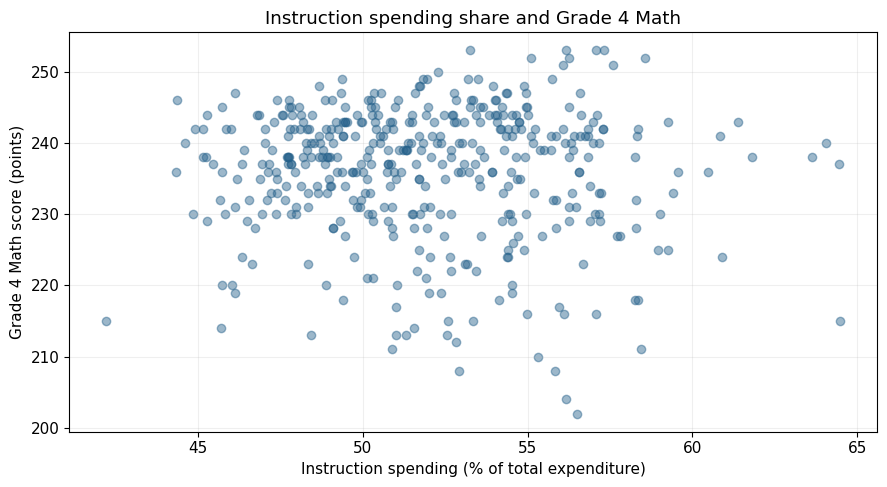

Observed state-years: 431; Pearson r: -0.04


In [9]:
# @@@ 6
# Plot observed pairs only; no imputation is used for EDA.
plot_data = model_df.dropna(subset=["instruction_share"])
fig, ax = plt.subplots()
ax.scatter(plot_data["instruction_share"] * 100, plot_data[target], alpha=0.45, color="#24608a")
ax.set(xlabel="Instruction spending (% of total expenditure)", ylabel="Grade 4 Math score (points)", title="Instruction spending share and Grade 4 Math")
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()
print(f"Observed state-years: {len(plot_data)}; Pearson r: {plot_data['instruction_share'].corr(plot_data[target]):.2f}")

Across 431 observed state-years, instruction spending share has almost no linear association with Grade 4 Math (Pearson r = -0.04). Scores vary substantially at similar shares. Repeated state-year observations do not establish a causal spending effect.

**Visualization 2**

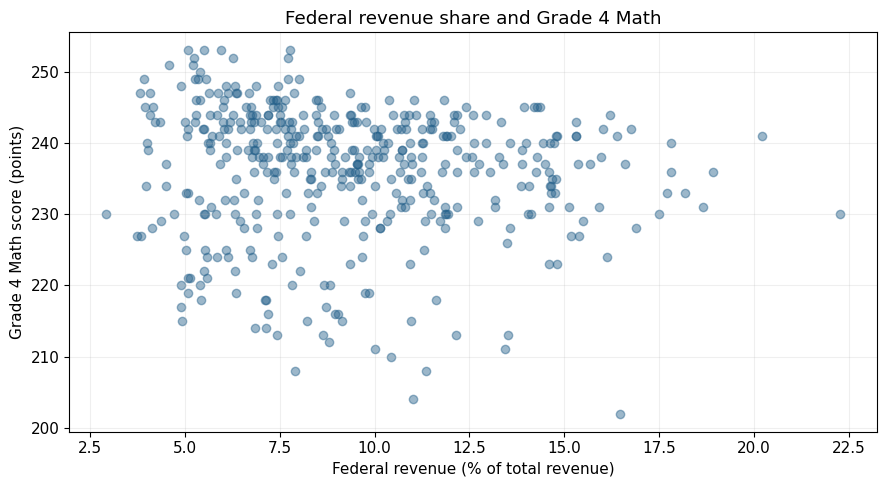

Observed state-years: 431; Pearson r: -0.10


In [10]:
# @@@ 7
# Each point represents one state-year with both measurements reported.
plot_data = model_df.dropna(subset=["federal_share"])
fig, ax = plt.subplots()
ax.scatter(plot_data["federal_share"] * 100, plot_data[target], alpha=0.45, color="#24608a")
ax.set(xlabel="Federal revenue (% of total revenue)", ylabel="Grade 4 Math score (points)", title="Federal revenue share and Grade 4 Math")
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()
print(f"Observed state-years: {len(plot_data)}; Pearson r: {plot_data['federal_share'].corr(plot_data[target]):.2f}")

Across 431 observed state-years, federal revenue share has a weak negative association with Grade 4 Math (Pearson r = -0.10), with broad scatter. This does not establish a harmful funding effect: funding mix may reflect underlying differences in need. Missing pairs are excluded.

<h2> Data Creation </h2>

_Use this space to create train/test data_

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
# @@@ 8
# Other test scores and identifiers are excluded from predictors.
X = model_df[features]
y = model_df[target]

In [13]:
# @@@ 9 
# Hold out the latest 20% of observed test years; keep each year in one split.
# This evaluates later-year prediction for states represented in training.
train_years, test_years = train_test_split(
    np.sort(model_df["YEAR"].unique()), test_size=0.2, shuffle=False
)
train_mask = model_df["YEAR"].isin(train_years)
X_train, X_test = X.loc[train_mask], X.loc[~train_mask]
y_train, y_test = y.loc[train_mask], y.loc[~train_mask]
assert X_train["YEAR"].max() < X_test["YEAR"].min()
print(f"Training: {len(X_train)} rows, years {train_years.tolist()}")
print(f"Testing: {len(X_test)} rows, years {test_years.tolist()}")
display(X_test.isna().mean().rename("test_missing_fraction"))

Training: 381 rows, years [1992, 2000, 2003, 2005, 2007, 2009, 2011, 2013]
Testing: 150 rows, years [2015, 2017, 2019]


YEAR                 0.000000
instruction_share    0.666667
federal_share        0.666667
Name: test_missing_fraction, dtype: float64

<h2> Prediction </h2>

ML Models [Resource](https://medium.com/@vijaya.beeravalli/comparison-of-machine-learning-classification-models-for-credit-card-default-data-c3cf805c9a5a)

In [14]:
# @@@ 10
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [15]:
# @@@ 11
# Fit medians and scaling only on training data to avoid leakage.
# Ridge regularization limits large coefficients; alpha is fixed before testing.
model = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), Ridge(alpha=1.0))

In [16]:
model.fit(X_train, y_train)

,steps,"[('simpleimputer', ...), ('standardscaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [17]:
y_pred = model.predict(X_test)

## Evaluation

Choose some metrics to evaluate the performance of your model, some of them are mentioned in the tutorial.

In [18]:
# @@@ 12
# Compare against predicting the training mean for every observation.
baseline = DummyRegressor(strategy="mean").fit(X_train, y_train)
results = []
for name, estimator in [("Ridge", model), ("Training-mean baseline", baseline)]:
    for split, inputs, actual in [("Train", X_train, y_train), ("Test", X_test, y_test)]:
        predicted = estimator.predict(inputs)
        results.append({"Model": name, "Split": split,
                        "MAE": mean_absolute_error(actual, predicted),
                        "RMSE": np.sqrt(mean_squared_error(actual, predicted)),
                        "R2": r2_score(actual, predicted)})
metrics = pd.DataFrame(results).set_index(["Model", "Split"])
display(metrics.round(3))
# Coefficients describe associations per training standard deviation, not causal effects.
display(pd.Series(model.named_steps["ridge"].coef_, index=features,
                  name="Standardized coefficient (score points)"))

MAE    RMSE     R2
Model                  Split                       
Ridge                  Train   4.216   5.299  0.689
                       Test   11.912  13.014 -6.238
Training-mean baseline Train   7.546   9.505  0.000
                       Test    5.485   6.575 -0.847

YEAR                 8.310531
instruction_share   -0.070559
federal_share       -3.432904
Name: Standardized coefficient (score points), dtype: float64

The held-out years are 2015, 2017, and 2019 (150 state-years). Ridge has test MAE **11.91 points**, RMSE **13.01**, and R² **−6.24**, compared with baseline MAE **5.49** and RMSE **6.58**. This model fails to improve on the training-mean baseline. Its positive linear year trend extrapolates poorly, and both financial shares are missing for two-thirds of test rows, requiring training-median imputation. These are limitations of this model and data, not evidence that funding has no relationship with achievement. No model settings were tuned against the test set. Future work could use lagged scores and a nonlinear time effect, selected using a separate chronological validation set.

We have copied over the graphs that visualize the model's performance on the training and testing set. 

Change `col_name` and modify the call to `plt.ylabel()` to isolate how a single predictor affects the model.

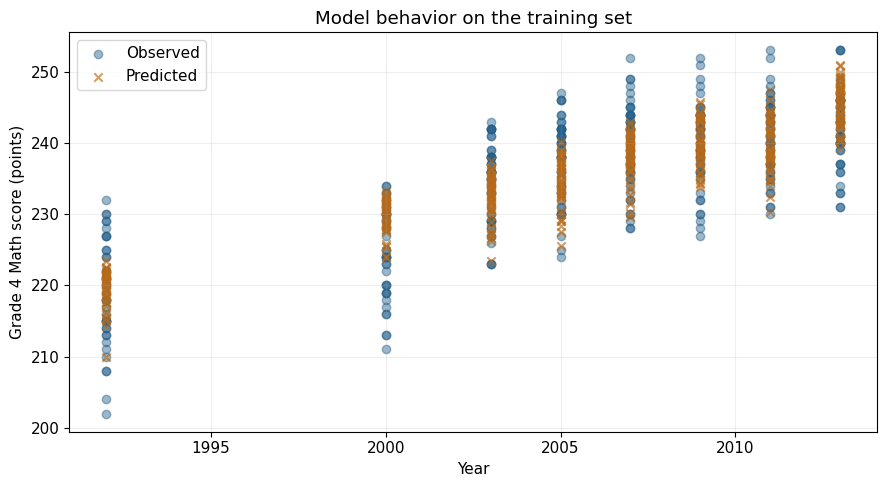

In [19]:
# @@@ 13
# Plot one predictor, but predictions still use all three features.
col_name = "YEAR"
fig, ax = plt.subplots()
ax.scatter(X_train[col_name], y_train, label="Observed", color="#24608a", alpha=0.45)
ax.scatter(X_train[col_name], model.predict(X_train), label="Predicted", color="#b86a19", marker="x", alpha=0.65)
ax.set(xlabel="Year", ylabel="Grade 4 Math score (points)", title="Model behavior on the training set")
ax.legend()
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

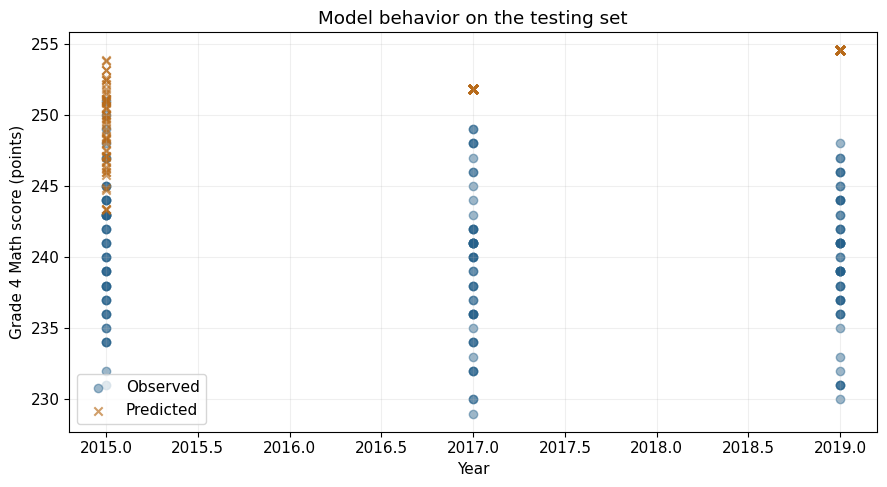

In [20]:
# @@@ 14
# Plot one predictor, but predictions still use all three features.
col_name = "YEAR"
fig, ax = plt.subplots()
ax.scatter(X_test[col_name], y_test, label="Observed", color="#24608a", alpha=0.45)
ax.scatter(X_test[col_name], model.predict(X_test), label="Predicted", color="#b86a19", marker="x", alpha=0.65)
ax.set(xlabel="Year", ylabel="Grade 4 Math score (points)", title="Model behavior on the testing set")
ax.legend()
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()